# The Multiple Regression Model

## Cholera outbreak

![John Snow](https://upload.wikimedia.org/wikipedia/commons/c/cc/John_Snow.jpg) [John Snow](https://en.wikipedia.org/wiki/John_Snow) was an English physicist famous for locating the source of the London cholera epidemic of 1854. At the time of the outbreak the germ theory of disease transmission was not yet developed and cholera was blamed on bad air. John Snow investigated the cases and concluded that the source of the outbreak is a water pump located on Broad Street. He was able to convince the city council to shut down the pump but people initially resisted his theory of water born transmission, because it seemed to be socially unacceptable.

![Cholera cases](http://blog.rtwilson.com/wp-content/uploads/2012/01/SnowMap_Points.png)

![Broad street pump](https://lookup.london/wp-content/uploads/2018/08/Photo-11-08-2018-13-44-18.jpg.webp)

## World War II

During World war 2 combat aviation played a crucial role but also suffered heavy casualties. British bomber command for example reports a death rate of about 46 percent over the entire war. In order to reduce the number of planes that were being shot down during mission, the military collected data on the damage taken from returning bombers in order to decide where to place armour on the planes.

![Flight](https://images.squarespace-cdn.com/content/v1/5497331ae4b0148a6141bd47/1563476799483-JXTY82K6EJ2Y6THNIN53/ke17ZwdGBToddI8pDm48kAY9gT9wm-2Z9KnmFRfe2dVZw-zPPgdn4jUwVcJE1ZvWQUxwkmyExglNqGp0IvTJZUJFbgE-7XRK3dMEBRBhUpzdMdQQVVUpiXVl6rYD3wsGGtpDQQshX7-5HE1V8UScgaHj4j2hNsP6urc280cwWcU/7.jpg)

![Flac damage on a bomber plane](https://www.old.bombercommandmuseum.ca/photos/p_airgunners1b.jpg)

![Bullet holes locations (histogram)](https://alearningadayblog.files.wordpress.com/2018/06/bombers.jpeg)

![](https://riskwerk.files.wordpress.com/2016/11/abraham-wald1.png)

# Two continuous predictors



In [ ]:
if (!require("tidyverse")) { install.packages("tidyverse") }

if (!require("GGally")) { install.packages("GGally") }

if (!require("maps")) {install.packages("maps")}

library(tidyverse)
library(GGally)

crime <- read_tsv("https://raw.githubusercontent.com/feb-uni-sofia/econometrics2020-solutions/master/data/crime.csv") %>% select(-I)


Rows: 67 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): County
dbl (4): C, I, HS, U

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


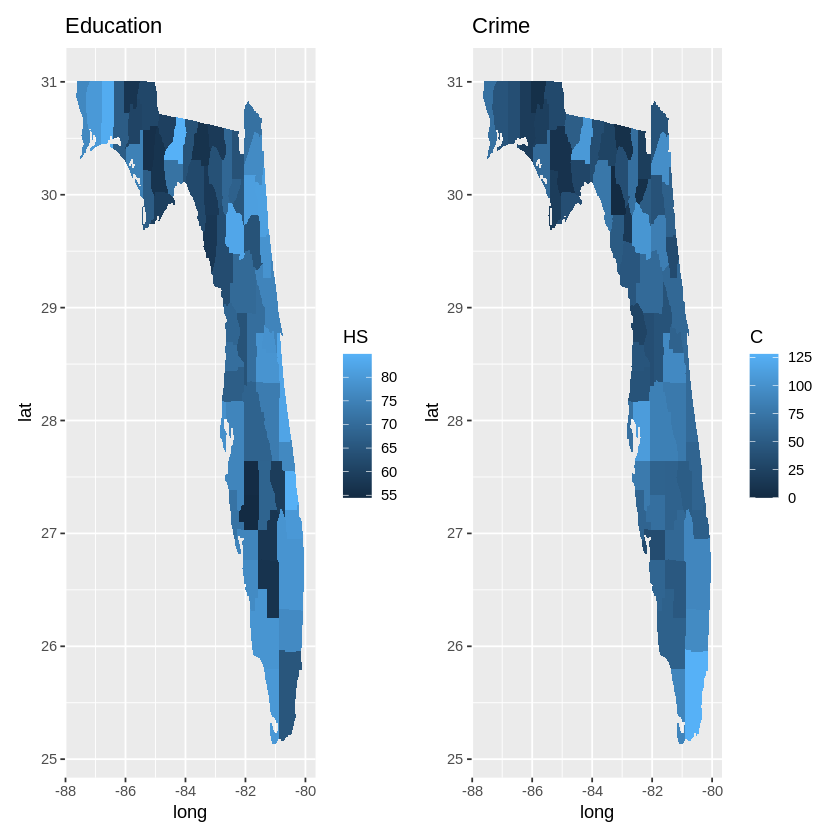

In [ ]:
## Code for illustration purposes only
us_counties <- map_data("county")
florida_counties <- us_counties %>%
  filter(region == "florida")
crime_match <- crime %>%
  mutate(
    County = str_to_lower(str_replace_all(County, "\\.", ""))
  )
county_name_compat <- c(
  "washington" = "washing",
  "santa rosa" = "santar",
  "suwannee" = "suwanee",
  "palm beach" = "palmb",
  "okeechobee" = "okeech",
  "indian river" = "indianr",
  "hillsborough" = "hillsbor",
  "miami-dade" = "dade"
)
florida_crime <- florida_counties %>%
  mutate(
    County = dplyr::recode(subregion, !!!county_name_compat),
    County = str_replace_all(County, "\\s", "")
  ) %>%
  left_join(crime_match, by = "County")
p1 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = U)) +
  geom_polygon() +
  labs(
    title = "Urbanisation"
  )
p2 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = HS)) +
  geom_polygon() +
  labs(
    title = "Education"
  )
p3 <- florida_crime %>%
  ggplot(aes(x = long, y = lat, group = group, fill = C)) +
  geom_polygon() +
  labs(
    title = "Crime"
  )
p2


Variables description:

-   `C`: number of crimes per 100,000 inhabitants
-   `HS`: share of high school graduates
-   `U`: share of persons living in urban areas

## First model: crime and education

$$
\underbrace{C_i}_{\text{Crime}} = \beta_0 + \beta_1 \underbrace{\text{HS}_i}_{\text{Share of persons with high school degree}} + \underbrace{e_i}_{\text{Random term}}, \quad i = 1,\ldots,n = 67
$$

In [ ]:
crime |>
  ggplot(aes(x = HS, y = C)) +
    geom_point() +
    xlim(c(0, 100)) +
    ylim(c(-60, 120)) +
    geom_abline(intercept = -50.8, slope = 1.48) +
    geom_vline(xintercept = c(0, mean(crime$HS)), color = "steelblue", lty = 2)

In [12]:
fit_C_HS <- lm(C ~ HS, data = crime)
summary(fit_C_HS)


Call:
lm(formula = C ~ HS, data = crime)

Residuals:
   Min     1Q Median     3Q    Max 
-43.74 -21.36  -4.82  17.42  82.27 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -50.8569    24.4507  -2.080   0.0415 *  
HS            1.4860     0.3491   4.257 6.81e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 25.12 on 65 degrees of freedom
Multiple R-squared:  0.218,	Adjusted R-squared:  0.206 
F-statistic: 18.12 on 1 and 65 DF,  p-value: 6.806e-05


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


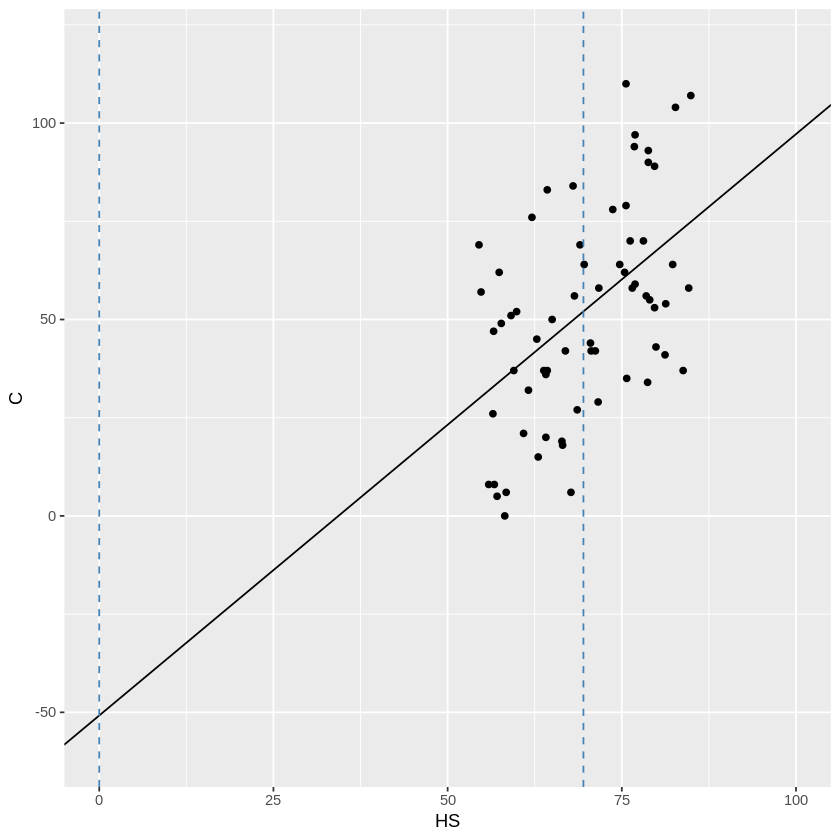

In [13]:
crime %>%
  ggplot(aes(x = HS, y = C)) +
    geom_point() +
    xlim(c(0, 100)) +
    ylim(c(-60, 120)) +
    geom_abline(intercept = -50.8, slope = 1.48) +
    geom_vline(xintercept = c(0, mean(crime$HS)), color = "steelblue", lty = 2)

## Third Model: Education and Urbanization

$$
\text{HS}_i = \beta_0 + \beta_1 U_i + e_i
$$



In [ ]:
# Fit the model and print the summary




## Graphical representation of the data



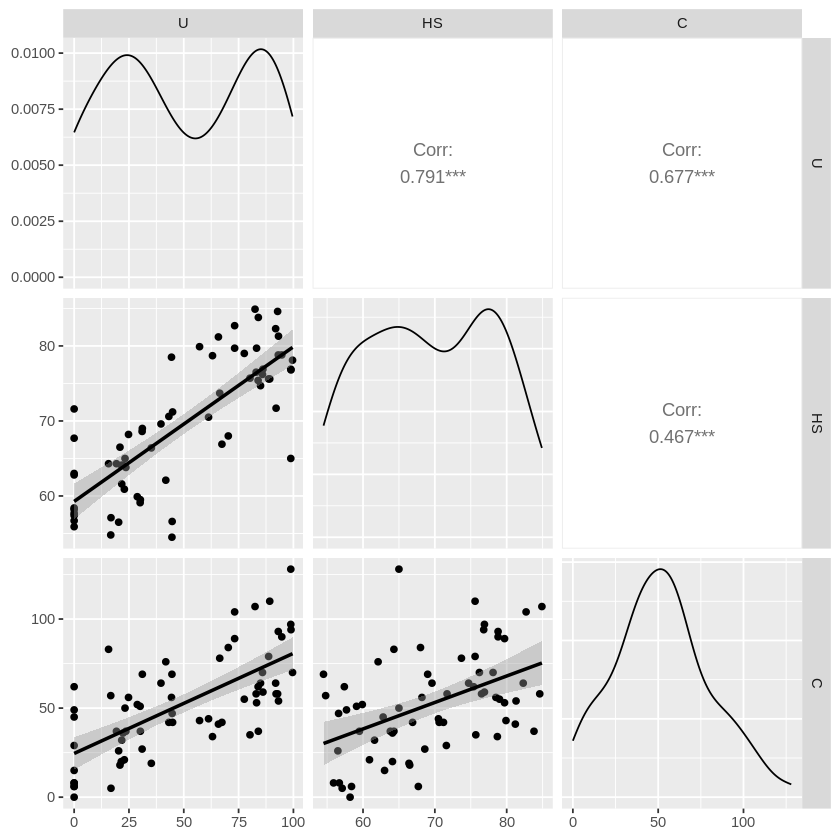

In [16]:
ggpairs(crime, columns = c(4, 3, 2), lower = list(continuous = "smooth"))


## Fourth Model: Crime, Education, and Urbanization

$$
C_i = \beta_0 + \beta_1 \text{HS}_i  + \beta_2 \text{U}_i + e_i
$$




Call:
lm(formula = C ~ 1 + HS + U, data = crime)

Residuals:
    Min      1Q  Median      3Q     Max 
-34.693 -15.742  -6.226  15.812  50.678 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  59.1181    28.3653   2.084   0.0411 *  
HS           -0.5834     0.4725  -1.235   0.2214    
U             0.6825     0.1232   5.539 6.11e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 20.82 on 64 degrees of freedom
Multiple R-squared:  0.4714,	Adjusted R-squared:  0.4549 
F-statistic: 28.54 on 2 and 64 DF,  p-value: 1.379e-09
